In [41]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [52]:
# Prompt
bit_stream = np.array([1, 0, 1, 1,0,0,0,1,0,1])

#### Alternet Mask Inversion

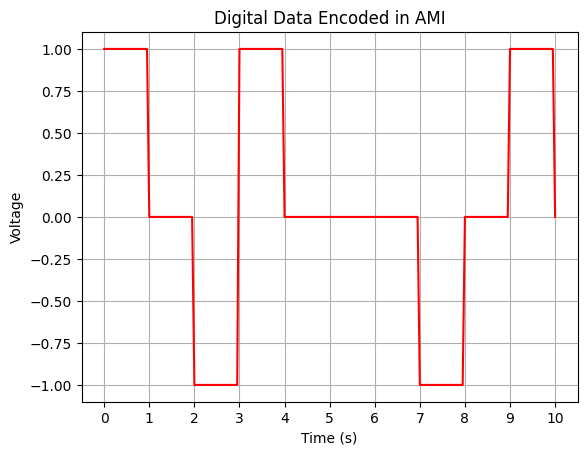

In [43]:

time = np.arange(0, 10.05, 0.05)  
bit_time = 1
no_of_points = int(bit_time / 0.05)

points_ones = np.ones(no_of_points) * -1
points_zeros = np.zeros(no_of_points)

output = []



for bit in bit_stream:
    if bit == 1:
        points_ones *= -1
        output.extend(points_ones)
    else:
        output.extend(points_zeros)

output.extend([0] * (len(time) - len(output)))

output_series = pd.Series(output, index=time)


plt.figure()
plt.plot(time, output_series, 'r')
plt.title('Digital Data Encoded in AMI')
plt.xlabel('Time (s)')
plt.ylabel('Voltage')
plt.grid(True)
plt.xticks(np.arange(0, max(time) + 1, 1))
plt.show()


#### B8RZ

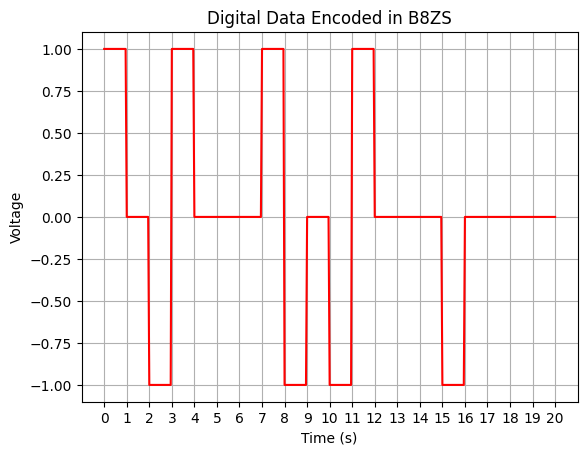

In [44]:
time = np.arange(0, 20.05, 0.05)

bit_stream = np.array([1, 0, 1, 1, 0,0,0,0,0,0,0,0,0,0,0,1])
bit_time = 1
no_of_points = int(bit_time / 0.05)

points_ones = np.ones(no_of_points)
points_zeros = np.zeros(no_of_points)

violation_1 = np.concatenate((np.tile(points_zeros, 3), points_ones, -points_ones, points_zeros, -points_ones, points_ones))
violation_n1 = np.concatenate((np.tile(points_zeros, 3), -points_ones, points_ones, points_zeros, points_ones, -points_ones))

output = []
prev_level = -1



i = 0
while i < len(bit_stream):
    if i + 7 < len(bit_stream):
        current_chunk = bit_stream[i:i + 8]
        if np.all(current_chunk == 0):
            if prev_level == 1:
                output.extend(violation_1)
            else:
                output.extend(violation_n1)
            i += 8
            continue

    if bit_stream[i] == 1:
        prev_level = -prev_level
        output.extend(points_ones * prev_level)
    else:
        output.extend(points_zeros)
    i += 1

output.extend([0] * (len(time) - len(output)))

plt.figure()
plt.plot(time, output, 'r')
plt.title('Digital Data Encoded in B8ZS')
plt.xlabel('Time (s)')
plt.ylabel('Voltage')
plt.grid(True)
plt.xticks(np.arange(0, max(time) + 1, 1))
plt.show()


In [45]:
# Prompt
bit_stream = np.array([1, 0, 1, 1, 0,1,0,0,1])

### Differntial Manchester and Manchester

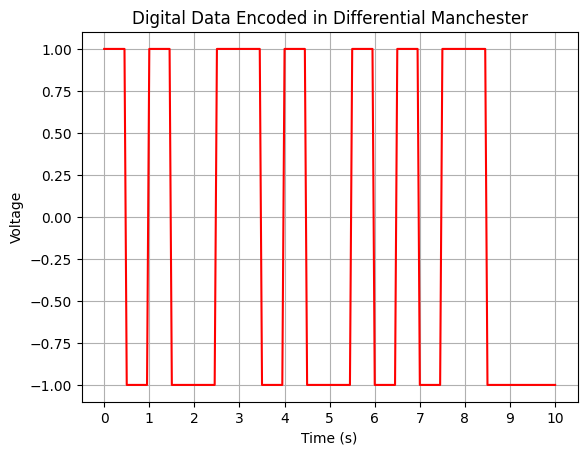

In [46]:
time = np.arange(0, 10.05, 0.05)

bit_time = 1
no_of_points = int(bit_time / 0.05)

prev_level = 1

output = []



for bit in bit_stream:
    if bit == 1:
        points_ones = np.concatenate((np.ones(int(no_of_points/2)) * prev_level, np.ones(int(no_of_points/2)) * -prev_level))
        prev_level = -prev_level
        output.extend(points_ones)
    else:
        points_zeros = np.concatenate((np.ones(int(no_of_points/2)) * -prev_level, np.ones(int(no_of_points/2)) * prev_level))
        output.extend(points_zeros)

output.extend([output[-1]] * (len(time) - len(output)))

plt.figure()
plt.plot(time, output, 'r')
plt.title('Digital Data Encoded in Differential Manchester')
plt.xlabel('Time (s)')
plt.ylabel('Voltage')
plt.grid(True)
plt.xticks(np.arange(0, max(time) + 1, 1))
plt.show()


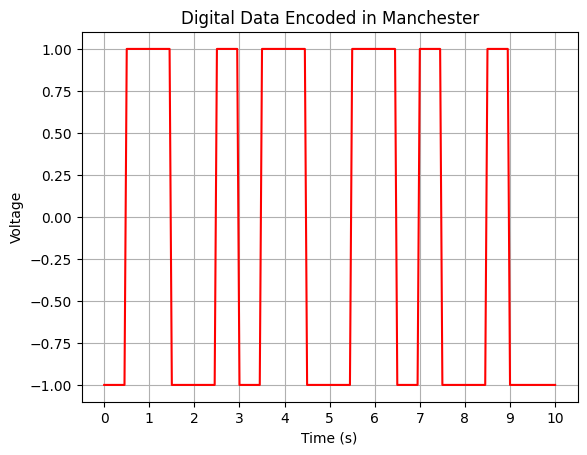

In [47]:
time = np.arange(0, 10.05, 0.05)

bit_time = 1
no_of_points = int(bit_time / 0.05)

points_ones = np.concatenate((np.ones(int(no_of_points/2)) * -1, np.ones(int(no_of_points/2))))
points_zeros = np.concatenate((np.ones(int(no_of_points/2)), np.ones(int(no_of_points/2)) * -1))

output = []

for bit in bit_stream:
    if bit == 1:
        output.extend(points_ones)
    else:
        output.extend(points_zeros)

output.extend([points_ones[0]] * (len(time) - len(output)))

plt.figure()
plt.plot(time, output, 'r')
plt.title('Digital Data Encoded in Manchester')
plt.xlabel('Time (s)')
plt.ylabel('Voltage')
plt.grid(True)
plt.xticks(np.arange(0, max(time) + 1, 1))
plt.show()


### NRZ and RZ

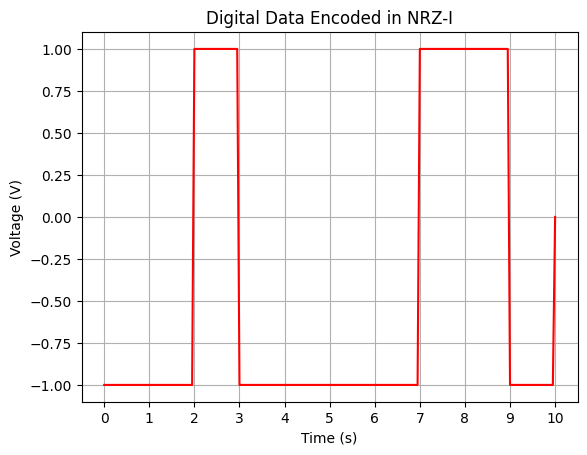

In [48]:
time = np.arange(0, 10.05, 0.05)
bit_stream = np.array([1, 0, 1, 1,0,0,0,1,0,1])
bit_time = 1
no_of_points = int(bit_time / 0.05)

points_ones = np.ones(no_of_points)

output = []

for bit in bit_stream:
    if bit == 1:
        points_ones *= -1
    output.extend(points_ones)

output.extend([0] * (len(time) - len(output)))

plt.figure()
plt.plot(time, output, 'r')
plt.title('Digital Data Encoded in NRZ-I')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.grid(True)
plt.xticks(np.arange(0, max(time) + 1, 1))
plt.show()


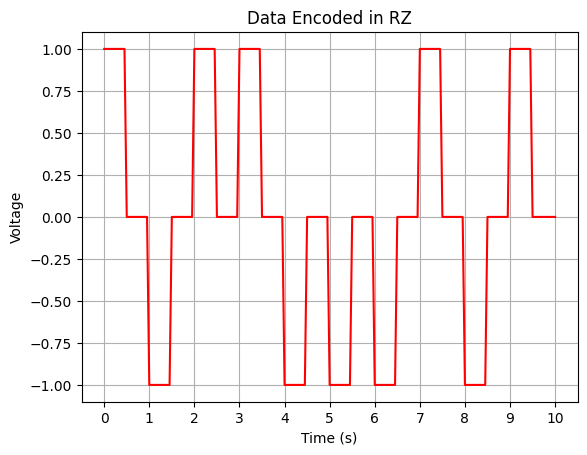

In [54]:
time = np.arange(0, 10.05, 0.05)

bit_time = 1
no_of_points = int(bit_time / 0.05)

points_ones = np.concatenate((np.ones(int(no_of_points/2)), np.zeros(int(no_of_points/2))))
points_zeros = np.concatenate((np.ones(int(no_of_points/2)) * -1, np.zeros(int(no_of_points/2))))

output = []



for bit in bit_stream:
    if bit == 1:
        output.extend(points_ones)
    else:
        output.extend(points_zeros)

output.extend([0] * (len(time) - len(output)))

plt.figure()
plt.plot(time, output, 'r')
plt.title('Data Encoded in RZ')
plt.xlabel('Time (s)')
plt.ylabel('Voltage')
plt.grid(True)
plt.xticks(np.arange(0, max(time) + 1, 1))
plt.show()
